# Recreating *Statistical Arbitrage in the Polish Equities Market* — on the Russian market

**Question.** Adamczyk & Dąbrowski (arXiv 2512.03073) run an Avellaneda–Lee (2008)
statistical-arbitrage strategy on Warsaw Stock Exchange data and report portfolio
Sharpe up to **2.63** and ~20% total return for 2017–2019. Does the same machine make
money on MOEX?

**Answer (spoiler).** The machinery transfers; the alpha does not. Over 2017–2019 the
gross (pre-fee) edge on the Russian top-60 universe is ≈ **zero**, every method lands
at or below the RUB cash baseline, and the paper's method ranking inverts. The single
period with a real edge is 2015–2016 — short-side driven and regime-local. This
notebook reproduces every step and every number behind that verdict.

**Companion files**

| file | role |
|---|---|
| `REPLICATION_SPEC.md` | the paper distilled: every parameter + Polish target numbers |
| `RU_ADAPTATION.md` | every Polish→Russian mapping decision |
| `RESULTS.md` | full written results |
| `moex_data.py` | data layer (MOEX ISS + dohod.ru, dividend adjustment, caching) |
| `statarb_pipeline.py` | the engine: factor models → OU → s-scores → backtest |
| `lstm_factors.py`, `run_lstm.py` | the per-stock LSTM method (§10) |
| `run_experiments.py` | the experiment driver that produced `results/` |

**How to run.** Everything below executes from the cached `data/` (built once by
`python3 moex_data.py`, ~20 min of MOEX ISS requests) and `results/`. Full notebook
runtime ≈ 2 minutes. Only the LSTM *training* is not re-run here (≈ 4 h for 240
models); its cached results are loaded and the exact rerun command is given.

## 0 · Environment and data

Dependencies: `numpy`, `pandas`, `pyarrow`, `matplotlib` (+ `torch` only for the LSTM).
The data layer cached everything under `data/`:

- `prices_close.parquet` — raw daily closes, 60 stocks, 2013-06…2020-12 (MOEX ISS candles)
- `prices_adj.parquet` — dividend-adjusted closes (built in §1)
- `indices.parquet` — MCFTR, MESMTR, RGBITR, 8 sector total-return indices, IMOEX, MCXSM
- `dividends.csv` — merged per-payment records (ISS ∪ dohod.ru)
- `basis_factors.json` — share-basis rescaling factors (§1)
- `ofz_1y.parquet`, `risk_free.json` — 1Y OFZ zero-coupon yields (MOEX `zcyc`)
- `universe.json` — the 60 tickers + the selection rule

In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import moex_data
from statarb_pipeline import (THRESHOLDS, backtest, build_panel_etf,
                              build_panel_pca, fit_ou_panel,
                              ols_residuals_multi, sharpe_by_year, trade_stats,
                              W_RESID, N_COV, KAPPA_MIN)
from run_experiments import PERIODS, prepare_data, build_panel, traded_mask

plt.rcParams.update({"figure.figsize": (9.5, 4.2), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
# one color per entity, consistent across every chart in this notebook
C = {"pca_const": "#2a78d6", "pca_var": "#1baf7a", "etf_real": "#eda100",
     "etf_real3": "#008300", "etf_sector": "#4a3aa7", "lstm": "#e34948",
     "cash": "#8d97a7"}
NAME = {"pca_const": "PCA r=15", "pca_var": "PCA var-r", "etf_real": "ETF sparse",
        "etf_real3": "ETF sparse+bonds", "etf_sector": "ETF sector", "lstm": "LSTM"}

d = moex_data.load_all()
print(f"{len(d['universe'])} stocks, {d['close'].index.min().date()} … "
      f"{d['close'].index.max().date()}")
print("risk-free (1Y OFZ period averages):",
      {k: f"{v:.2%}" for k, v in d["rf"].items()})
print(", ".join(d["universe"]))

60 stocks, 2013-06-03 … 2020-12-30
risk-free (1Y OFZ period averages): {'2015-2016': '10.39%', '2017-2019': '7.34%', '2020': '4.86%'}
AFKS, AFLT, AKRN, ALRS, BANE, BANEP, BSPB, CHMF, FEES, FESH, GAZP, GCHE, GMKN, HYDR, IRAO, IRGZ, KBTK, LKOH, LNTA, LSRG, MAGN, MGNT, MOEX, MRKC, MRKP, MSNG, MSRS, MTLR, MTLRP, MTSS, MVID, NKNC, NKNCP, NLMK, NMTP, NVTK, OGKB, PHOR, PIKK, PLZL, POLY, QIWI, RASP, ROSN, RSTI, RTKM, RTKMP, SBER, SBERP, SNGS, SNGSP, SVAV, TATN, TATNP, TGKA, TRMK, TRNFP, VSMO, VTBR, YNDX


## 1 · Universe and dividend-adjusted prices

**Universe rule** (mirrors the paper's WIG20+mWIG40 = "60 large+mid caps, one fixed
list"): score every ticker by average weight in yearly **MOEXBMI** (Broad Market Index)
snapshots 2015–2020 from the ISS analytics endpoint, require ≥95% trading-day coverage
from 2014-03, take the top 60. Delistings (URKA, MFON, DIXY…) and late listings (FIVE,
TCSG, POLY…) drop out — the same survivorship the paper accepts; it *flatters* results,
which makes the negative verdict conservative.

**Two data gotchas solved here** (both invisible until they bite):

1. **MOEX candles are retroactively split-adjusted, dividends are not.** GMKN and
   TRNFP did 100:1 splits in 2024, PLZL 10:1 in 2025, VTBR a 5000:1 reverse split —
   so candle history is in *today's* share basis while dividends are as-paid per *old*
   share. Fix: per-stock basis factor = candle price ÷ as-traded price on reference
   dates (two dates ⇒ detects any unhandled in-window split); dividends are multiplied
   by it before adjusting.
2. **ISS dividend history is incomplete pre-2018** (SBER starts 2019, MTSS/NVTK 2018).
   Fix: merge with dohod.ru per-payment tables (registry-close date + value), ISS
   winning where both exist. Ex-date under T+2 = the trading day after the last day a
   buy still settles on/before registry close.

Back-adjustment is the standard multiplicative chain: on each ex-date all prices ≤ the
cum-day are multiplied by $(P_{cum} - D)/P_{cum}$.

share-basis factors ≠ 1: {'GMKN': 0.01, 'PLZL': 0.1, 'TRNFP': 0.01, 'VTBR': 5000.0}

519 dividend records across 54 tickers


,ticker,close_date,value,src
0,SBER,2014-06-17,3.20,dohod
1,SBER,2015-06-15,0.45,dohod
2,SBER,2016-06-14,1.97,dohod
3,SBER,2017-06-14,6.00,dohod
4,SBER,2018-06-26,12.00,dohod
5,SBER,2019-06-13,16.00,iss
6,SBER,2020-10-05,18.70,iss


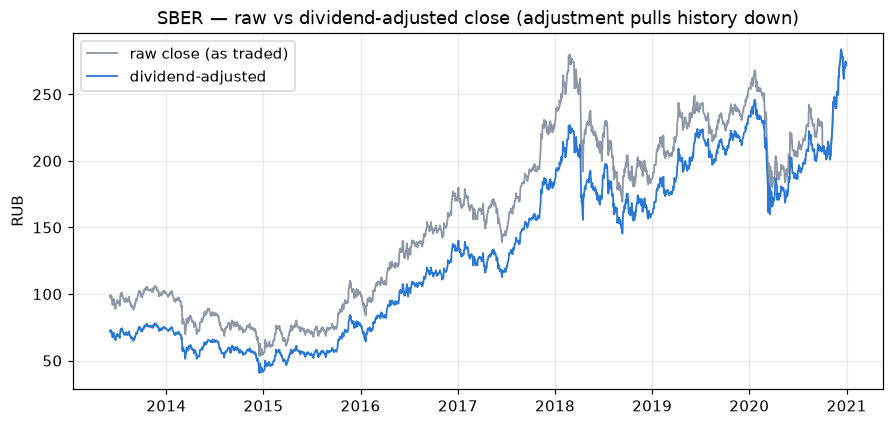

In [2]:
basis = json.loads((moex_data.DATA_DIR / "basis_factors.json").read_text())
print("share-basis factors ≠ 1:",
      {k: v for k, v in basis.items() if v != 1.0})

div = pd.read_csv(moex_data.DATA_DIR / "dividends.csv", parse_dates=["close_date"])
print(f"\n{len(div)} dividend records across {div.ticker.nunique()} tickers")
display(div[div.ticker == "SBER"][["ticker", "close_date", "value", "src"]]
        .reset_index(drop=True))

fig, ax = plt.subplots()
ax.plot(d["close"].index, d["close"]["SBER"], lw=1.2, color=C["cash"],
        label="raw close (as traded)")
ax.plot(d["adj"].index, d["adj"]["SBER"], lw=1.2, color=C["pca_const"],
        label="dividend-adjusted")
ax.set_title("SBER — raw vs dividend-adjusted close (adjustment pulls history down)")
ax.set_ylabel("RUB"); ax.legend(); plt.show()

## 2 · Returns panel

Simple returns on adjusted close (the paper's convention; OU math relies on the
small-return ≈ log-return approximation). Suspended days become 0-returns, and a
`traded` mask (raw close present) gates *new* positions so we never "open" a trade in
a halted stock.

In [3]:
data = prepare_data()          # returns / traded mask / ETF factor sets / rf
R = data["returns"]
print("returns panel:", R.shape, "|", R.index.min().date(), "…", R.index.max().date())
print(f"median daily vol across stocks: {R.std().median():.2%}")
print(f"factor sets: { {k: list(v.columns) for k, v in data['factor_sets'].items()} }")

returns panel: (1908, 60) | 2013-06-04 … 2020-12-30
median daily vol across stocks: 1.92%
factor sets: {'etf_real': ['MCFTR', 'MESMTR'], 'etf_real3': ['MCFTR', 'MESMTR', 'RGBITR'], 'etf_sector': ['MEOGTR', 'MEMMTR', 'MEFNTR', 'MECNTR', 'MEEUTR', 'METLTR', 'METNTR', 'MECHTR']}


## 3 · Step one of the method: build the replicating portfolio, three ways

The strategy replaces classic pairs trading's "asset B" with a **synthetic replica**
of each stock built from tradable systematic factors. The three methods differ *only*
here; everything downstream is identical.

**3a · PCA eigenportfolios.** On the previous calendar year's 252 returns: normalize
$Y_i = (R_i - \bar R_i)/\sigma_i$, take the correlation matrix
$\hat\Sigma = Y^\top Y/(n-1)$, eigen-decompose, and set eigenportfolio weights
$Q^{(k)} = v^{(k)}/\sigma$ (inverse-vol scaling — gotcha #2 in the spec). Factor
returns are $F^{(k)} = R\,Q^{(k)}$. Either **r = 15** factors (Avellaneda's choice)
or the smallest r explaining ≥ **55%** of variance. Eigenvectors refit **yearly**;
loadings β refit **daily**.

**3b · "Existing ETFs"** (sparse): Poland used three size-tier TR ETFs
(WIG20TR/mWIG40TR/sWIG80TR). Russia has two tiers — **MCFTR** (large, tracked by FXRL
from 03.2016) and **MESMTR** (SMID TR) — plus a `+RGBITR` (state-bond TR) variant.

**3c · "Artificial ETFs"** (dense): Poland's 14 sector indices → Russia's **8 sector
total-return indices** (MEOGTR, MEMMTR, MEFNTR, MECNTR, MEEUTR, METLTR, METNTR, MECHTR).

A key diagnostic up front: is the Russian market "too concentrated" for an APT
decomposition? **No** — the eigenvalue spectrum needs 13–16 PCs for 55% of variance,
essentially Poland's 16–18. The failure we'll see is *not* a degenerate factor
structure.

,λ1,λ2,r for 55%
year,,,
2015,22.0%,9.3%,9
2016,20.3%,5.9%,13
2017,15.5%,4.6%,15
2018,18.2%,4.8%,15
2019,24.0%,4.7%,13
2020,12.7%,4.5%,16


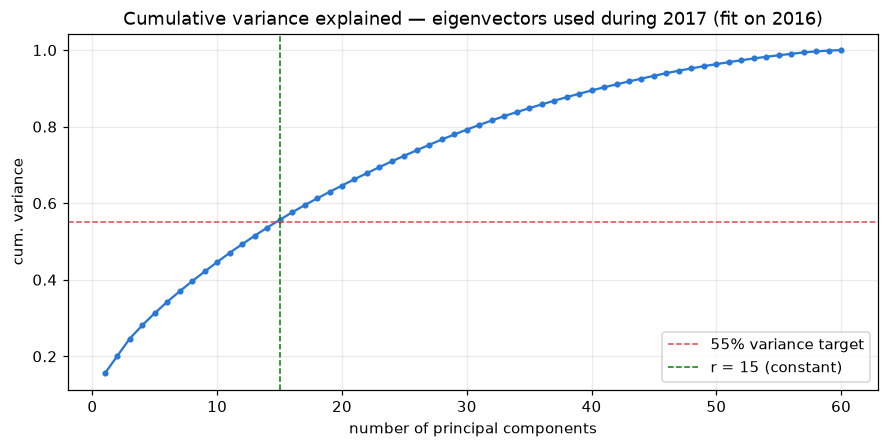

In [4]:
def eig_spectrum(year):
    end = R.index.searchsorted(pd.Timestamp(f"{year}-01-01"))
    win = R.values[max(0, end - N_COV):end]
    std = win.std(0, ddof=1); std[std == 0] = 1
    Y = (win - win.mean(0)) / std
    ev = np.linalg.eigvalsh((Y.T @ Y) / (len(win) - 1))[::-1]
    return ev / ev.sum()

rows = []
for y in range(2015, 2021):
    s = eig_spectrum(y)
    rows.append({"year": y, "λ1": f"{s[0]:.1%}", "λ2": f"{s[1]:.1%}",
                 "r for 55%": int(np.searchsorted(np.cumsum(s), 0.55) + 1)})
display(pd.DataFrame(rows).set_index("year"))

s17 = eig_spectrum(2017)
fig, ax = plt.subplots()
ax.plot(range(1, 61), np.cumsum(s17), marker="o", ms=3, color=C["pca_const"])
ax.axhline(0.55, color=C["lstm"], lw=1, ls="--", label="55% variance target")
ax.axvline(15, color=C["etf_real3"], lw=1, ls="--", label="r = 15 (constant)")
ax.set_title("Cumulative variance explained — eigenvectors used during 2017 (fit on 2016)")
ax.set_xlabel("number of principal components"); ax.set_ylabel("cum. variance")
ax.legend(); plt.show()

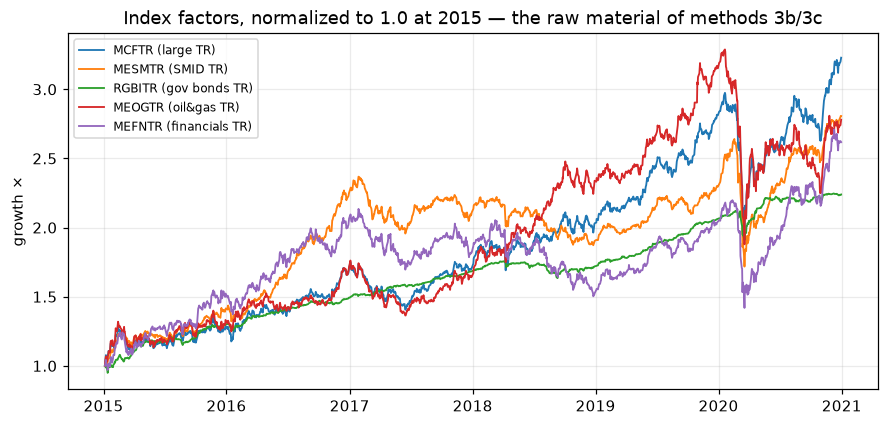

In [5]:
idx = d["indices"].reindex(d["adj"].index).ffill()
fig, ax = plt.subplots()
for name, col in [("MCFTR (large TR)", "MCFTR"), ("MESMTR (SMID TR)", "MESMTR"),
                  ("RGBITR (gov bonds TR)", "RGBITR"),
                  ("MEOGTR (oil&gas TR)", "MEOGTR"), ("MEFNTR (financials TR)", "MEFNTR")]:
    s = idx[col].loc["2015":]
    ax.plot(s.index, s / s.iloc[0], lw=1.2, label=name)
ax.set_title("Index factors, normalized to 1.0 at 2015 — the raw material of methods 3b/3c")
ax.set_ylabel("growth ×"); ax.legend(fontsize=8); plt.show()

## 4 · From factors to a signal — one concrete stock-day

For stock $i$ on day $t$, over the trailing **W = 120** days ending at $t$:

1. **APT regression** $\;R^i_u = \alpha_i\,dt + \sum_k \beta_{ik} F^k_u + dI^i_u$
   (daily OLS with intercept; residuals $dI$ are the idiosyncratic increments).
2. **Cumulate** $\;I_k = \sum_{j\le k} dI_j$. With an intercept the residuals sum to
   zero, so $I_W = 0$ exactly — the path is a bridge (spec §2 notes this).
3. **Fit OU via AR(1)**: $I_k = \phi_0 + \phi_1 I_{k-1} + \zeta$, then
   $\kappa = -252\ln\phi_1$, $\;\mu = \phi_0/(1-\phi_1)$,
   $\;\sigma_{eq} = \sqrt{\mathrm{Var}(\zeta)/(1-\phi_1^2)}$. Valid only if
   $\phi_1 \in (0,1)$.
4. **s-score** $\;s_t = (I_W - \mu)/\sigma_{eq} = -\mu/\sigma_{eq}$: how many
   equilibrium standard deviations the residual sits from its OU mean.
5. **Tradeability filter**: only names with $\kappa > 4$ (mean reversion faster than
   ~63 days, $\tau = 252/\kappa$) may *open* positions.

SBER on 2017-06-01:  kappa = 18.1  (tau = 14 days)   s-score = +0.57   beta_1..3 = [0.004 0.001 0.003]
cross-section that day: 60/60 valid OU fits, 60 pass kappa>4


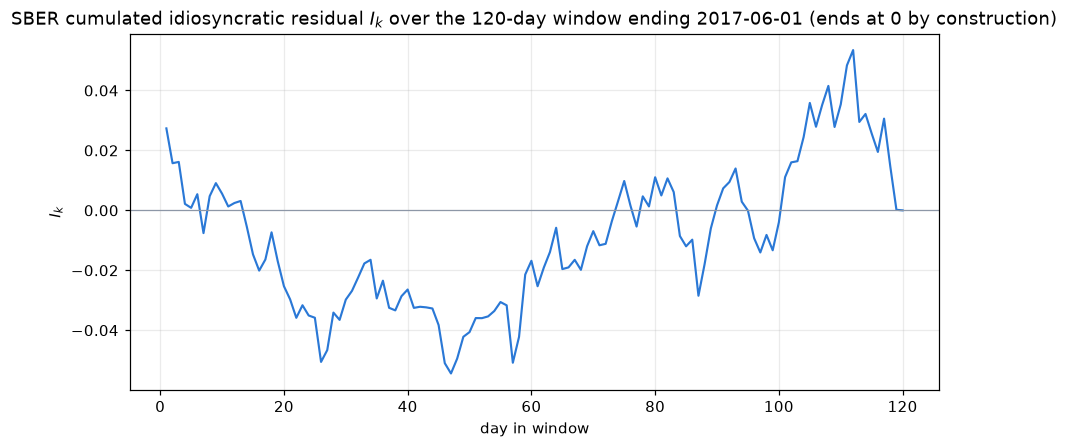

In [6]:
day = pd.Timestamp("2017-06-01")
ti = R.index.searchsorted(day)
Rwin = R.values[ti - W_RESID + 1: ti + 1]              # trailing 120 days incl. day

end16 = R.index.searchsorted(pd.Timestamp("2017-01-01"))
win16 = R.values[end16 - N_COV:end16]
std = win16.std(0, ddof=1); std[std == 0] = 1
Y = (win16 - win16.mean(0)) / std
ev, vec = np.linalg.eigh((Y.T @ Y) / (len(win16) - 1))
order = np.argsort(ev)[::-1]
Q = (vec[:, order[:15]] / std[:, None])                # eigenportfolio weights, r=15

F = Rwin @ Q                                           # factor returns over the window
resid, beta = ols_residuals_multi(F, Rwin)             # daily OLS, all 60 at once
I = np.cumsum(resid, axis=0)
kappa, s, valid = fit_ou_panel(I)

si = R.columns.get_loc("SBER")
print(f"SBER on {day.date()}:  kappa = {kappa[si]:.1f}  (tau = {252/kappa[si]:.0f} days)"
      f"   s-score = {s[si]:+.2f}   beta_1..3 = {np.round(beta[:3, si], 3)}")
print(f"cross-section that day: {np.isfinite(s).sum()}/60 valid OU fits, "
      f"{(kappa > KAPPA_MIN).sum()} pass kappa>4")

fig, ax = plt.subplots()
ax.plot(range(1, W_RESID + 1), I[:, si], color=C["pca_const"], lw=1.4)
ax.axhline(0, color=C["cash"], lw=0.8)
ax.set_title(f"SBER cumulated idiosyncratic residual $I_k$ over the 120-day window "
             f"ending {day.date()} (ends at 0 by construction)")
ax.set_xlabel("day in window"); ax.set_ylabel("$I_k$"); plt.show()

## 5 · Signal panels for whole periods

The engine is two-stage: **stage 1** precomputes, for every (day, stock), the s-score,
κ, and the replica weight vector in *instrument space* (stocks for PCA/LSTM, indices
for the ETF methods — the weights are frozen when a trade opens, so the hedge leg is
priced with them later). **Stage 2** is then a cheap state machine, which is what makes
the threshold grid search in §8 nearly free. One panel takes ~a second: the per-day
work is a single `lstsq` of the 120×16 factor block against all 60 stocks at once plus
a vectorized AR(1).

   [pca_const] r by year: {2017: 15, 2018: 15, 2019: 15}
panel built in 0.2s — 758 days × 60 stocks


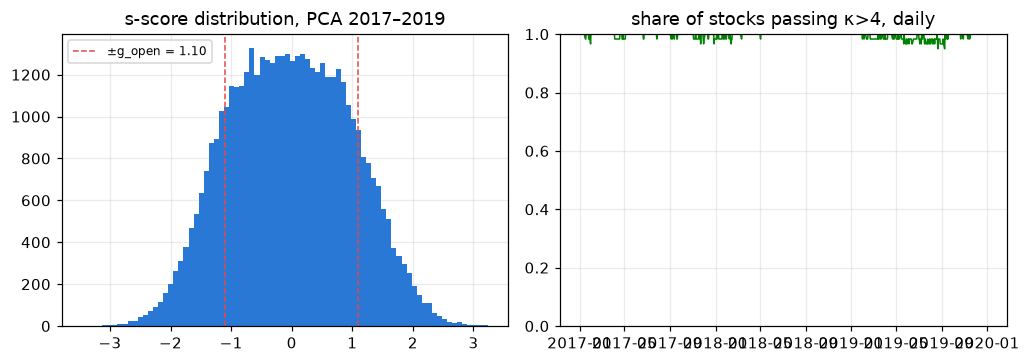

s std = 1.00 | share of stock-days with |s|>1.10: 30.0% | mean κ>4 share: 100%


In [7]:
t0 = time.time()
panel = build_panel_pca(R, PERIODS["2017-2019"], r_factors=15, method_name="pca_const")
print(f"panel built in {time.time() - t0:.1f}s — {panel.s.shape[0]} days × "
      f"{panel.s.shape[1]} stocks")

sv = panel.s[np.isfinite(panel.s)]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].hist(sv, bins=80, color=C["pca_const"])
for g, c, lab in [(1.10, C["lstm"], "±g_open = 1.10")]:
    axes[0].axvline(-g, color=c, ls="--", lw=1, label=lab)
    axes[0].axvline(+g, color=c, ls="--", lw=1)
axes[0].set_title("s-score distribution, PCA 2017–2019"); axes[0].legend(fontsize=8)
share = np.nanmean(panel.kappa > KAPPA_MIN, axis=1)
axes[1].plot(panel.dates, share, color=C["etf_real3"], lw=1)
axes[1].set_title("share of stocks passing κ>4, daily"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()
print(f"s std = {sv.std():.2f} | share of stock-days with |s|>1.10: "
      f"{(np.abs(sv) > 1.10).mean():.1%} | mean κ>4 share: {share.mean():.0%}")

## 6 · Trading rules and the paper's accounting

**Rule template** (four cutoffs, symmetric open/close):

| | condition |
|---|---|
| open long | $s < -g_{ol}$ (and κ>4, and >60 days before period end) |
| open short | $s > +g_{os}$ |
| close long | $s > -g_{cl}$ |
| close short | $s < +g_{cs}$ |

Paper's Polish-optimized values: PCA **(1.10, −0.50)** — note the *negative* close
cutoff: exits wait for the residual to overshoot to the *other* side of the mean;
LSTM (1.10, −0.15); sparse ETF (2.10, +0.75); sector ETF (1.95, +0.40).

**Accounting** (per the paper): 60 independent per-stock traders; one open position
per stock; per-trade scale $\Lambda = \frac{2}{60}E_t$ frozen at open, as are the
replica weights. Per-trade P&L for a long over $[t_0,t_1]$, in net returns:

$$P = \Lambda\Big[(r_{stock} - H) - (e^{r_f\Delta}-1)(1 - q^M)
- c\big(e^{r_f\Delta}|1+q^M| + |(1+r_{stock}) + (q^M + H)|\big)\Big]$$

where $H$ = hedge-leg PLN-return (frozen weights × compounded instrument returns) and
$q^M = \sum_k \beta_k$ = money in the replica. *(Implementation war story: the spec's
formula is written in gross returns; misreading it as net charges every trade a phantom
$(1-q^M)$ of notional — our synthetic-data harness caught exactly that before any real
run.)* Equity is realized-only with automatic cash compounding,
$E_t = 100\,e^{r_f t} + \sum_{closed} P_i\,e^{r_f(t-t_1)}$ — so with RUB rates,
**"did nothing" earns +24.5% over 2017–2019 and +4.9% over 2020**. We therefore always
report $\alpha$ = final equity − cash baseline. Annualized Sharpe per calendar year:
$S_y = (252\bar r_d - r_f)/(\sqrt{252}\,\sigma_d)$.

PCA r=15, Polish thresholds, 2017–2019:  total -2.07%   alpha -26.7 RUB   Sharpe {2017: -1.08, 2018: 0.88, 2019: -2.66}   677 trades, win 58%, median hold 41d


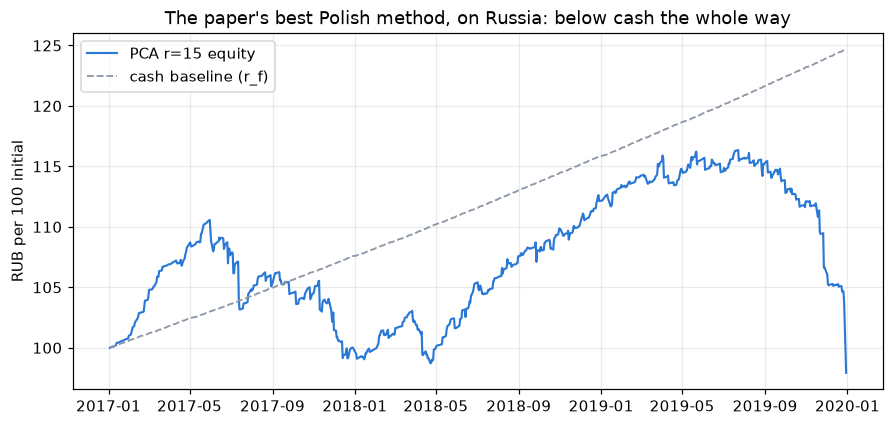

In [8]:
rf = data["rf"]["2017-2019"]
res = backtest(panel, 1.10, -0.50, r_f=rf, traded=traded_mask(data, panel))
cash = pd.Series(100 * np.exp(rf * np.arange(len(panel.dates)) / 252),
                 index=panel.dates)
ts = trade_stats(res["trades"])
print(f"PCA r=15, Polish thresholds, 2017–2019:  total {res['final_return']:+.2%}"
      f"   alpha {res['equity'].iloc[-1] - cash.iloc[-1]:+.1f} RUB"
      f"   Sharpe { {y: round(v, 2) for y, v in res['sharpe_by_year'].items()} }"
      f"   {ts['n']} trades, win {ts['win_rate']:.0%}, median hold {ts['median_hold_days']:.0f}d")

fig, ax = plt.subplots()
ax.plot(res["equity"].index, res["equity"], color=C["pca_const"], lw=1.4,
        label="PCA r=15 equity")
ax.plot(cash.index, cash, color=C["cash"], lw=1.2, ls="--", label="cash baseline (r_f)")
ax.set_title("The paper's best Polish method, on Russia: below cash the whole way")
ax.set_ylabel("RUB per 100 initial"); ax.legend(); plt.show()

## 7 · Transfer test — every method, the paper's thresholds

Now the same run for all five deterministic methods × both periods (LSTM joins from
its cached run in §10). For each: total return, **α vs cash**, per-year Sharpe, trade
stats — next to the Polish numbers from the paper (spec §6).

In [9]:
methods = ["pca_const", "pca_var", "etf_real", "etf_real3", "etf_sector"]
panels, results, rows = {}, {}, []
for period in ("2017-2019", "2020"):
    rf_p = data["rf"][period]
    for m in methods:
        p = build_panel(m, data, period)
        panels[(m, period)] = p
        r = backtest(p, *THRESHOLDS[m], r_f=rf_p, traded=traded_mask(data, p))
        results[(m, period)] = r
        cash_end = 100 * np.exp(rf_p * (len(p.dates) - 1) / 252)
        t = trade_stats(r["trades"])
        rows.append({
            "period": period, "method": NAME[m],
            "total": f"{r['final_return']:+.1%}",
            "alpha, RUB": round(r["equity"].iloc[-1] - cash_end, 1),
            "Sharpe by yr": " / ".join(f"{v:+.2f}" for v in r["sharpe_by_year"].values()),
            "trades": t["n"], "win": f"{t['win_rate']:.0%}",
        })
tt = pd.DataFrame(rows).set_index(["period", "method"])
display(tt)
print("Poland 2017–2019 (paper): PCA +20% (Sharpe 2.63/1.01/−1.16), LSTM ≈+10%, "
      "ETFs ≈+5%;  2020: only ETFs profit (+3–5%), PCA blows up (−1.39).")

   [pca_const] r by year: {2017: 15, 2018: 15, 2019: 15}


   [pca_var] r by year: {2017: 15, 2018: 15, 2019: 13}


   [pca_const] r by year: {2020: 15}
   [pca_var] r by year: {2020: 16}


total  alpha, RUB           Sharpe by yr  trades  \
period    method                                                                
2017-2019 PCA r=15           -2.1%       -26.7  -1.08 / +0.88 / -2.66     677   
          PCA var-r          -1.7%       -26.3  -1.08 / +0.88 / -2.28     675   
          ETF sparse        +22.9%        -1.8  -0.86 / +0.23 / +0.28     188   
          ETF sparse+bonds  +25.0%         0.4  -0.86 / +0.60 / +0.96     194   
          ETF sector        +18.6%        -6.1  -0.88 / -0.38 / -0.41     276   
2020      PCA r=15           +4.6%        -0.3                  -0.01     214   
          PCA var-r          +4.5%        -0.4                  -0.03     207   
          ETF sparse         +5.0%         0.1                  +0.05      55   
          ETF sparse+bonds   +3.9%        -1.1                  -0.53      56   
          ETF sector         +4.0%        -0.9                  -0.22      74   

                            win  
period    method                 
2017-2019 PCA r=15          58%  
          PCA var-r         59%  
          ETF sparse        60%  
          ETF sparse+bonds  59%  
          ETF sector        56%  
2020      PCA r=15          59%  
          PCA var-r         59%  
          ETF sparse        47%  
          ETF sparse+bonds  46%  
          ETF sector        57%

Poland 2017–2019 (paper): PCA +20% (Sharpe 2.63/1.01/−1.16), LSTM ≈+10%, ETFs ≈+5%;  2020: only ETFs profit (+3–5%), PCA blows up (−1.39).


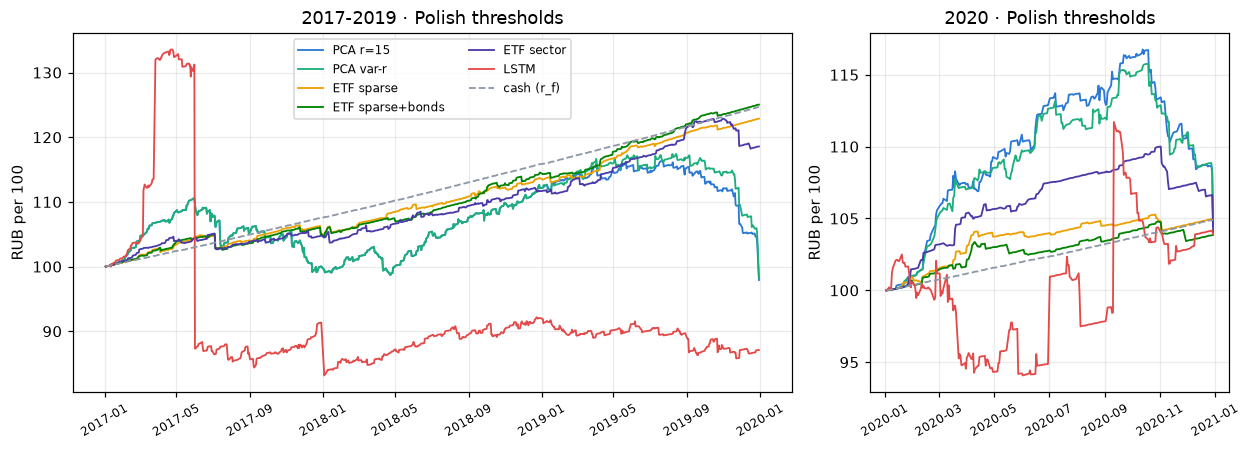

In [10]:
lstm_eq = {p: pd.read_csv(f"results/equity_lstm_{p}_paper_thr.csv", index_col=0,
                          parse_dates=True)["E"] for p in ("2017-2019", "2020")}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2),
                         gridspec_kw={"width_ratios": [2, 1]})
for axi, period in zip(axes, ("2017-2019", "2020")):
    rf_p = data["rf"][period]
    for m in methods:
        e = results[(m, period)]["equity"]
        axi.plot(e.index, e, lw=1.2, color=C[m], label=NAME[m])
    e = lstm_eq[period]
    axi.plot(e.index, e, lw=1.2, color=C["lstm"], label="LSTM")
    n = len(results[("pca_const", period)]["equity"])
    cash = 100 * np.exp(rf_p * np.arange(n) / 252)
    axi.plot(results[("pca_const", period)]["equity"].index, cash,
             color=C["cash"], ls="--", lw=1.2, label="cash (r_f)")
    axi.set_title(f"{period} · Polish thresholds")
    axi.set_ylabel("RUB per 100")
    axi.tick_params(axis="x", labelsize=8, rotation=30)
axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 8 · Re-optimizing thresholds on 2015–2016 (the paper's own procedure)

Maybe Polish thresholds just don't suit Russia? The paper grid-searched its cutoffs on
2015–2016 with final profit as the objective — we repeat that *on Russian data*:
$g_{open} \in [0.8, 2.4]$, $g_{close} \in [-0.8, 1.0]$, step 0.1, $g_{close} <
g_{open}$. Because stage-1 panels are cached, ~280 combinations take ~12 s per method.
The two live cells below re-derive PCA and sector-ETF; the saved JSON covers the rest.

In [11]:
from run_experiments import GRID_OPEN, GRID_CLOSE

def grid(method):
    p = panels.get((method, "2015-2016")) or build_panel(method, data, "2015-2016")
    panels[(method, "2015-2016")] = p
    tm, rf_p = traded_mask(data, p), data["rf"]["2015-2016"]
    best = None
    for go in GRID_OPEN:
        for gc in GRID_CLOSE:
            if gc >= go: continue
            r = backtest(p, float(go), float(gc), r_f=rf_p, compute_mtm=False, traded=tm)
            if best is None or r["final_return"] > best[2]:
                best = (float(go), float(gc), r["final_return"])
    return best

t0 = time.time()
for m in ("pca_const", "etf_sector"):
    go, gc, prof = grid(m)
    print(f"{NAME[m]:12s} best (g_open, g_close) = ({go:+.2f}, {gc:+.2f})"
          f"   in-sample 2015–16 profit {prof:+.1%}")
print(f"[{time.time() - t0:.0f}s]  full saved grid:")
opt = json.loads(Path("results/optimized_thresholds.json").read_text())
display(pd.DataFrame(opt).T[["g_open", "g_close", "profit", "n_trades"]])
print("cash baseline 2015–16 = +23.0% — note the sparse-ETF methods can't even beat "
      "cash IN-SAMPLE at a 10.4% risk-free rate.")

   [pca_const] r by year: {2015: 15, 2016: 15}


PCA r=15     best (g_open, g_close) = (+1.30, +0.90)   in-sample 2015–16 profit +123.3%


ETF sector   best (g_open, g_close) = (+1.70, +0.80)   in-sample 2015–16 profit +47.5%
[24s]  full saved grid:


,g_open,g_close,profit,n_trades
pca_const,1.3,0.9,1.232987,674.0
pca_var,1.2,0.5,1.212235,592.0
etf_real,2.4,1.0,0.186142,54.0
etf_real3,2.4,1.0,0.178977,60.0
etf_sector,1.7,0.8,0.475011,322.0


cash baseline 2015–16 = +23.0% — note the sparse-ETF methods can't even beat cash IN-SAMPLE at a 10.4% risk-free rate.


In [12]:
rows = []
for period in ("2017-2019", "2020"):
    rf_p = data["rf"][period]
    for m in methods:
        p = panels[(m, period)]
        r = backtest(p, opt[m]["g_open"], opt[m]["g_close"], r_f=rf_p,
                     traded=traded_mask(data, p))
        cash_end = 100 * np.exp(rf_p * (len(p.dates) - 1) / 252)
        rows.append({"period": period, "method": NAME[m],
                     "g": f"({opt[m]['g_open']:+.2f}, {opt[m]['g_close']:+.2f})",
                     "total": f"{r['final_return']:+.1%}",
                     "alpha, RUB": round(r["equity"].iloc[-1] - cash_end, 1),
                     "trades": r["n_trades"]})
display(pd.DataFrame(rows).set_index(["period", "method"]))
print("Out-of-sample verdict unchanged: RU-tuned thresholds do not resurrect the "
      "signal — PCA still −16…−24 RUB vs cash over 2017–2019.")

g   total  alpha, RUB  trades
period    method                                                      
2017-2019 PCA r=15          (+1.30, +0.90)   +8.3%       -16.4    1092
          PCA var-r         (+1.20, +0.50)   +1.2%       -23.5     934
          ETF sparse        (+2.40, +1.00)  +22.3%        -2.4      78
          ETF sparse+bonds  (+2.40, +1.00)  +23.4%        -1.3      86
          ETF sector        (+1.70, +0.80)  +21.4%        -3.3     502
2020      PCA r=15          (+1.30, +0.90)   +4.2%        -0.7     289
          PCA var-r         (+1.20, +0.50)   +4.1%        -0.8     277
          ETF sparse        (+2.40, +1.00)   +4.3%        -0.6      21
          ETF sparse+bonds  (+2.40, +1.00)   +5.2%         0.3      22
          ETF sector        (+1.70, +0.80)   +6.3%         1.4     136

Out-of-sample verdict unchanged: RU-tuned thresholds do not resurrect the signal — PCA still −16…−24 RUB vs cash over 2017–2019.


## 9 · The exception: 2015–2016 — and what it really was

The RU-tuned PCA thresholds earn **+123%** on the optimization period itself (gross
of fees **+96.6 RUB** per 100 of capital — cash made +23). Three facts before calling
it "the strategy works":

1. it is **short-side driven**: shorts +115.7 RUB (65% win), longs −38.1 RUB — the
   book was fading single-name spikes in the thin, violent post-2014-crash market,
   and mid-cap borrow in 2015 Russia was scarce, so part of this is unrealizable;
2. it is **broad, not a one-stock artifact** (top-3 names = 19% of gross P&L);
3. it **dies out-of-sample**: the same thresholds lose −16.4 RUB on 2017–2019.

The cell below goes to trade level and finds the real mechanism — **the strategy is a
tail bet, not an edge**. The *typical* trade is statistically the same in both regimes
(trimmed mean +0.36% vs +0.39%, median +1.30% vs +1.05%, win rate 64% vs 65%) and in
both it earns almost exactly its own ~0.4% round-trip cost. The entire two-year profit
is one fat right tail in **Q1 2015** — the December-2014 ruble-crisis unwind, at 42%
market volatility vs 26% later. Strip that quarter and the other 563 trades *lose*
money. So "it worked in 2015–16" means "it monetized one quarter of post-crisis
dispersion" — which reframes the Polish result too: 2017–19 Warsaw may simply have been
a dispersion-rich regime.

In [13]:
def gross_trades(period, g=(1.30, 0.90)):
    p = panels_by[period]
    r = backtest(p, *g, r_f=data["rf"][period], traded=traded_mask(data, p),
                 cost=0.0, compute_mtm=False)
    return pd.DataFrame([{"date": p.dates[t.t_open], "ret": t.pnl / t.scale * 100,
                          "pnl": t.pnl, "gross_exp": np.abs(t.w_vec).sum()}
                         for t in r["trades"]])

panels_by = {p: panels[("pca_const", p)] if ("pca_const", p) in panels
             else build_panel("pca_const", data, p) for p in ("2015-2016", "2017-2019")}
g15, g17 = gross_trades("2015-2016"), gross_trades("2017-2019")
stat = lambda t: pd.Series({
    "n trades": len(t), "median": f"{t.ret.median():+.2f}%",
    "trimmed mean (5%)": f"{t.ret.clip(t.ret.quantile(.05), t.ret.quantile(.95)).mean():+.2f}%",
    "mean": f"{t.ret.mean():+.2f}%", "win rate": f"{(t.ret > 0).mean():.0%}"})
display(pd.DataFrame({"2015–2016": stat(g15), "2017–2019": stat(g17)}))

q1 = g15.date <= pd.Timestamp("2015-04-01")
print(f"Q1-2015:            {q1.sum():3d} trades, mean {g15[q1].ret.mean():+6.2f}%/trade,"
      f" P&L {g15[q1].pnl.sum():+6.1f} RUB")
print(f"rest of 2015–2016:  {(~q1).sum():3d} trades, mean {g15[~q1].ret.mean():+6.2f}%/trade,"
      f" P&L {g15[~q1].pnl.sum():+6.1f} RUB   <- loses money!")
print(f"\nnot a leverage artifact: Q1-15 gross exposure sum|beta| median "
      f"{g15[q1].gross_exp.median():.2f} vs {g15[~q1].gross_exp.median():.2f} for the rest")
print(f"market vol (median stock, annualized): Q1-2015 "
      f"{R.loc['2015-01-01':'2015-04-01'].std().median() * np.sqrt(252):.0%}"
      f"  vs 2017–2019 {R.loc['2017':'2019'].std().median() * np.sqrt(252):.0%}")

,2015–2016,2017–2019
n trades,674,1092
median,+1.30%,+1.05%
trimmed mean (5%),+0.36%,+0.39%
mean,+4.17%,+0.02%
win rate,64%,65%


Q1-2015:            111 trades, mean +25.61%/trade, P&L +101.1 RUB
rest of 2015–2016:  563 trades, mean  -0.06%/trade, P&L   -4.6 RUB   <- loses money!

not a leverage artifact: Q1-15 gross exposure sum|beta| median 2.75 vs 3.03 for the rest
market vol (median stock, annualized): Q1-2015 42%  vs 2017–2019 26%


2015–16, PCA (1.30, +0.90): total +123.3% | trading P&L net +77.6 / gross +96.6 RUB | 674 trades, median hold 8d


,sum,count,win
side,,,
long,-38.13,308,0.57
short,115.72,366,0.65


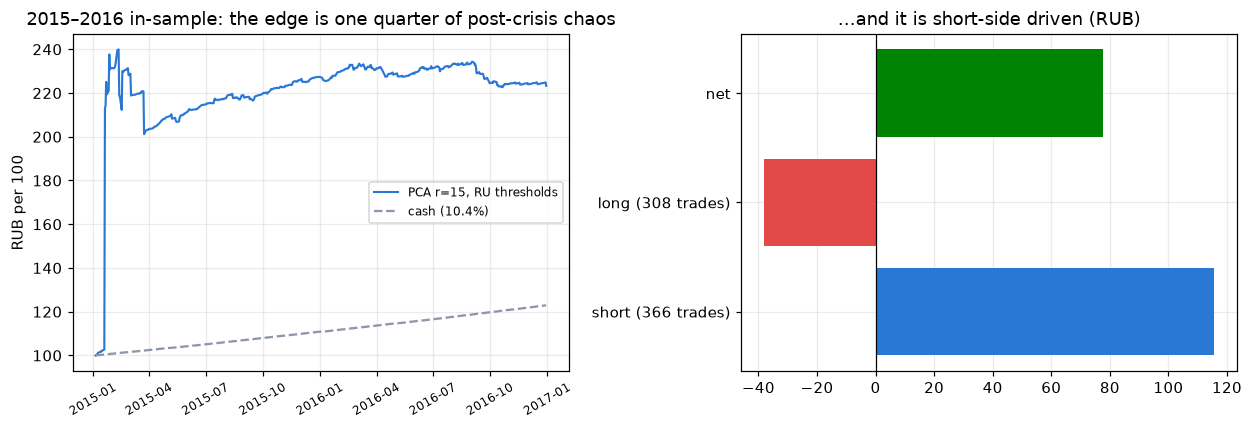

worst 5: {'RTKM': np.float64(-20.2), 'RSTI': np.float64(-12.1), 'RTKMP': np.float64(-10.5), 'FESH': np.float64(-10.3), 'BSPB': np.float64(-7.4)}
best 5:  {'POLY': np.float64(16.6), 'VTBR': np.float64(16.6), 'MAGN': np.float64(18.7), 'SBER': np.float64(26.6), 'AFKS': np.float64(34.2)}


In [14]:
p1516 = panels[("pca_const", "2015-2016")]
rf_p = data["rf"]["2015-2016"]
r1516 = backtest(p1516, 1.30, 0.90, r_f=rf_p, traded=traded_mask(data, p1516))
r1516_free = backtest(p1516, 1.30, 0.90, r_f=rf_p, cost=0.0, compute_mtm=False,
                      traded=traded_mask(data, p1516))
tr = pd.DataFrame([{"stock": t.stock, "side": t.side, "pnl": t.pnl,
                    "hold": t.t_close - t.t_open} for t in r1516["trades"]])
print(f"2015–16, PCA (1.30, +0.90): total {r1516['final_return']:+.1%} | trading "
      f"P&L net {tr.pnl.sum():+.1f} / gross {sum(t.pnl for t in r1516_free['trades']):+.1f} RUB "
      f"| {len(tr)} trades, median hold {tr.hold.median():.0f}d")
bys = tr.groupby(tr.side.map({1: 'long', -1: 'short'}))["pnl"].agg(["sum", "count",
      lambda x: (x > 0).mean()]).rename(columns={"<lambda_0>": "win"})
display(bys.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
cash = 100 * np.exp(rf_p * np.arange(len(p1516.dates)) / 252)
axes[0].plot(r1516["equity"].index, r1516["equity"], color=C["pca_const"], lw=1.4,
             label="PCA r=15, RU thresholds")
axes[0].plot(p1516.dates, cash, color=C["cash"], ls="--", label="cash (10.4%)")
axes[0].set_title("2015–2016 in-sample: the edge is one quarter of post-crisis chaos")
axes[0].set_ylabel("RUB per 100"); axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", labelsize=8, rotation=30)
side_pnl = tr.groupby(tr.side.map({1: 'long', -1: 'short'}))["pnl"].sum()
axes[1].barh(["short (366 trades)", "long (308 trades)", "net"],
             [side_pnl["short"], side_pnl["long"], tr.pnl.sum()],
             color=[C["pca_const"], C["lstm"], C["etf_real3"]])
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("…and it is short-side driven (RUB)")
plt.tight_layout(); plt.show()

by_stock = tr.groupby("stock")["pnl"].sum().sort_values()
print("worst 5:", dict(by_stock.head(5).round(1)))
print("best 5: ", dict(by_stock.tail(5).round(1)))

## 10 · The LSTM method (the paper's novel contribution)

Per spec §3B: **one model per stock** — a stacked 2-layer LSTM (hidden 64) that reads
the other 59 stocks' returns over the 120-day window and outputs a 59-vector $\beta_t$
at every step; replica return $X_t^\top\beta_t$; loss = window-MSE + $10^{-5}$·L1,
Adam, batch 16; **retrained yearly** on the prior 3 years and run from 120 days before
each year (its warmup deliberately overlaps the training span, as in the paper). The
residual $dI_t = R_t - X_t^\top\beta_t$ feeds the *same* OU pipeline — but with no
intercept, so here $I_W \ne 0$.

Training 240 stock-year models took ≈ 4 h (Apple-silicon GPU); the notebook loads the
cached result. To reproduce from scratch: `python3 run_lstm.py` (models cache to
`data/lstm/`, safe to interrupt/resume).

Two findings:

- **worst transfer of all**: −12.9% over 2017–2019 (α **−37.4 RUB**) vs ≈+10% in
  Poland — its overshoot exits (close long only at $s > +0.15$) hold ~20 days on a
  dead signal, bleeding fees + the money-market spread;
- a structural instability PCA/ETF don't have: the net hedge notional $q^M = \sum\beta$
  is **unconstrained** (L1 = 1e-5 shrinks individual weights, not their sum), so a few
  trades carry $|q^M| \gg 1$ and produce ±8–12 RUB single-trade swings — the early-2017
  spike below. The paper flags its LSTM hyperparameters as unoptimized; this is what
  that costs.

LSTM 2017-2019: total -12.9%  alpha -37.6 RUB  Sharpe {'2017': -0.2, '2018': -0.6, '2019': -2.27}  trades 711 (win 61%, hold 20d)
LSTM 2020: total +3.9%  alpha -1.0 RUB  Sharpe {'2020': 0.03}  trades 261 (win 49%, hold 12d)


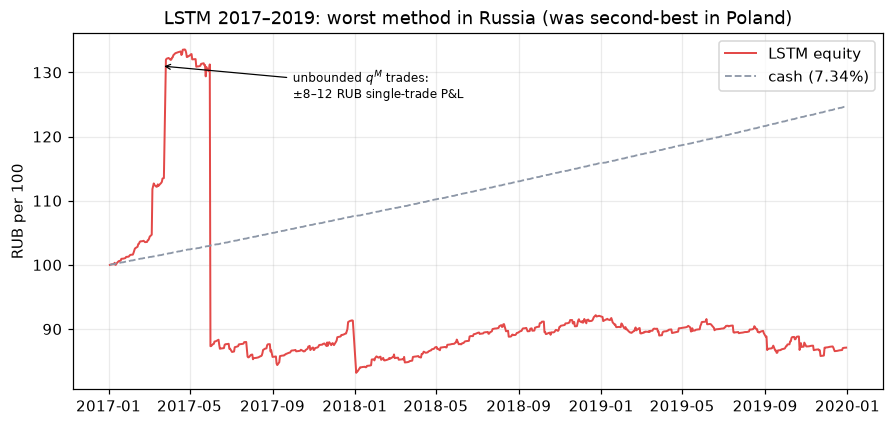

In [15]:
lstm_sum = json.loads(Path("results/summary_lstm.json").read_text())
for r in lstm_sum:
    n = len(lstm_eq[r["period"]])
    cash_end = 100 * np.exp(data["rf"][r["period"]] * (n - 1) / 252)
    print(f"LSTM {r['period']}: total {r['final_return']:+.1%}  "
          f"alpha {lstm_eq[r['period']].iloc[-1] - cash_end:+.1f} RUB  "
          f"Sharpe { {y: round(v, 2) for y, v in r['sharpe_by_year'].items()} }  "
          f"trades {r['trades']['n']} (win {r['trades']['win_rate']:.0%}, "
          f"hold {r['trades']['median_hold_days']:.0f}d)")

fig, ax = plt.subplots()
e = lstm_eq["2017-2019"]
n = len(e)
cash = 100 * np.exp(data["rf"]["2017-2019"] * np.arange(n) / 252)
ax.plot(e.index, e, color=C["lstm"], lw=1.3, label="LSTM equity")
ax.plot(e.index, cash, color=C["cash"], ls="--", lw=1.2, label="cash (7.34%)")
ax.annotate("unbounded $q^M$ trades:\n±8–12 RUB single-trade P&L",
            xy=(pd.Timestamp("2017-03-20"), 131), fontsize=8,
            xytext=(pd.Timestamp("2017-10-01"), 126),
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_title("LSTM 2017–2019: worst method in Russia (was second-best in Poland)")
ax.set_ylabel("RUB per 100"); ax.legend(); plt.show()

## 11 · Conclusions

| | Poland (paper) | Russia (this replication) |
|---|---|---|
| PCA 2017–19 | **+20%**, Sharpe up to 2.63 — best | −2.1%, **α −26.7 RUB**, gross edge −0.1 RUB — signal is dead |
| LSTM 2017–19 | ≈+10% — promising | −12.9%, **α −37.4 RUB** — worst |
| ETF 2017–19 | ≈+5% — weakest, stable | +19…+25% total ≈ cash; α −6…+0.4 RUB |
| 2020 stress | PCA blows up; only ETFs profit | nothing blows up, nothing profits: all within ±1.4 RUB of cash |
| Method ranking | PCA > LSTM > ETF | inverted: **whoever trades least loses least** |

1. **The pipeline replicates; the alpha does not.** Every mechanical element ports and
   behaves sanely (validated on synthetic OU data, where the same engine earns +170%).
   What Russia 2017–2019 lacks is the raw material: residual mean reversion worth more
   than ~0.4% per round trip.
2. **Not the factor structure** — r(55%) = 13–16 ≈ Poland's 16–18. The APT
   decomposition is fine.
3. **It is a crisis-dispersion bet, not an income stream** (§9). The typical Russian
   trade earns ≈+0.4% gross in *both* regimes — exactly its own transaction cost — so
   expected value is zero plus a tail. The tail arrived once, in Q1 2015 (+101 RUB from
   111 trades at 42% vol) and never again. Production use would need a volatility/regime
   filter, borrow-aware costs, and the expectation of dormancy most of the time.
4. **RUB cash at 7–10% raises the bar**: a hedged strategy must beat a baseline the
   paper's accounting hands out for free at Poland's 1.5%.
5. **The paper's cost model flatters everyone** (measured here): fees are charged on the
   *net* replica notional |1+q^M| ≈ 2, but the replica's *gross* book Σ|β| has median 3.0
   (p95 5.5, max 32) for PCA — real costs are ~2–3× what the formula charges, so these
   already-negative α's are, if anything, optimistic.

**Caveats** (details in `RESULTS.md` §7): survivorship-flattered fixed universe (makes
the negative verdict conservative); no borrow fees; sector/SMID indices not directly
investable pre-2018 (paper splices identically); QIWI pre-2016 dividends missing;
realized-only Sharpe convention as in the paper.

## 12 · Figures

`make_figures.py` renders the same story as eight annotated, presentation-ready PNGs in
`figures/` (each with a caption; index in `figures/README.md`) — the anatomy of one real
trade, the return decomposition, the tail-bet diagnostic, equity curves, the α
scoreboard, the 2015–16 regime, gross-vs-net, and the Poland/Russia inversion.

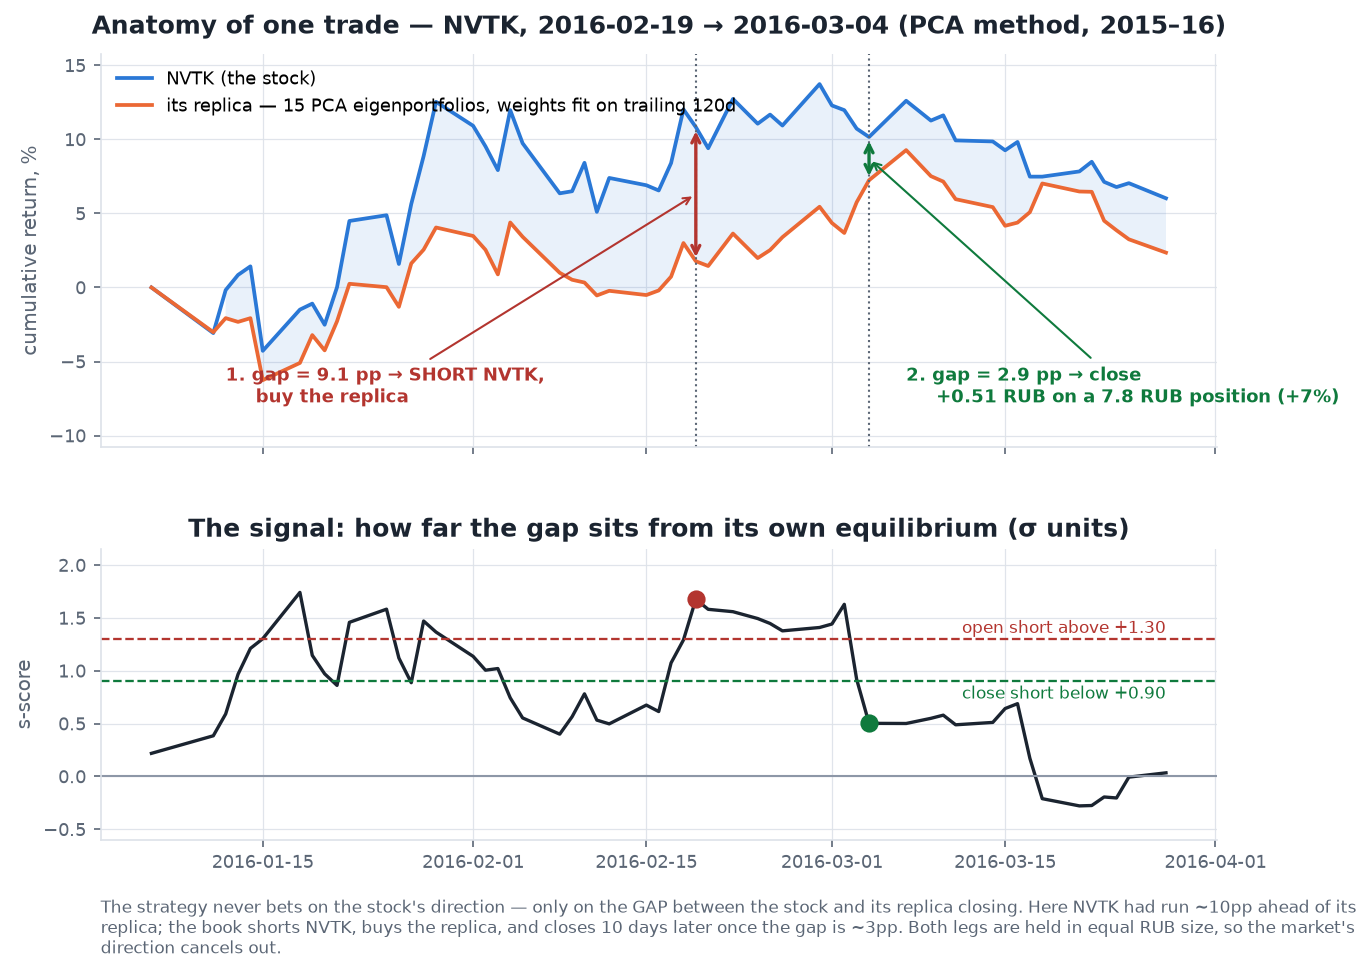

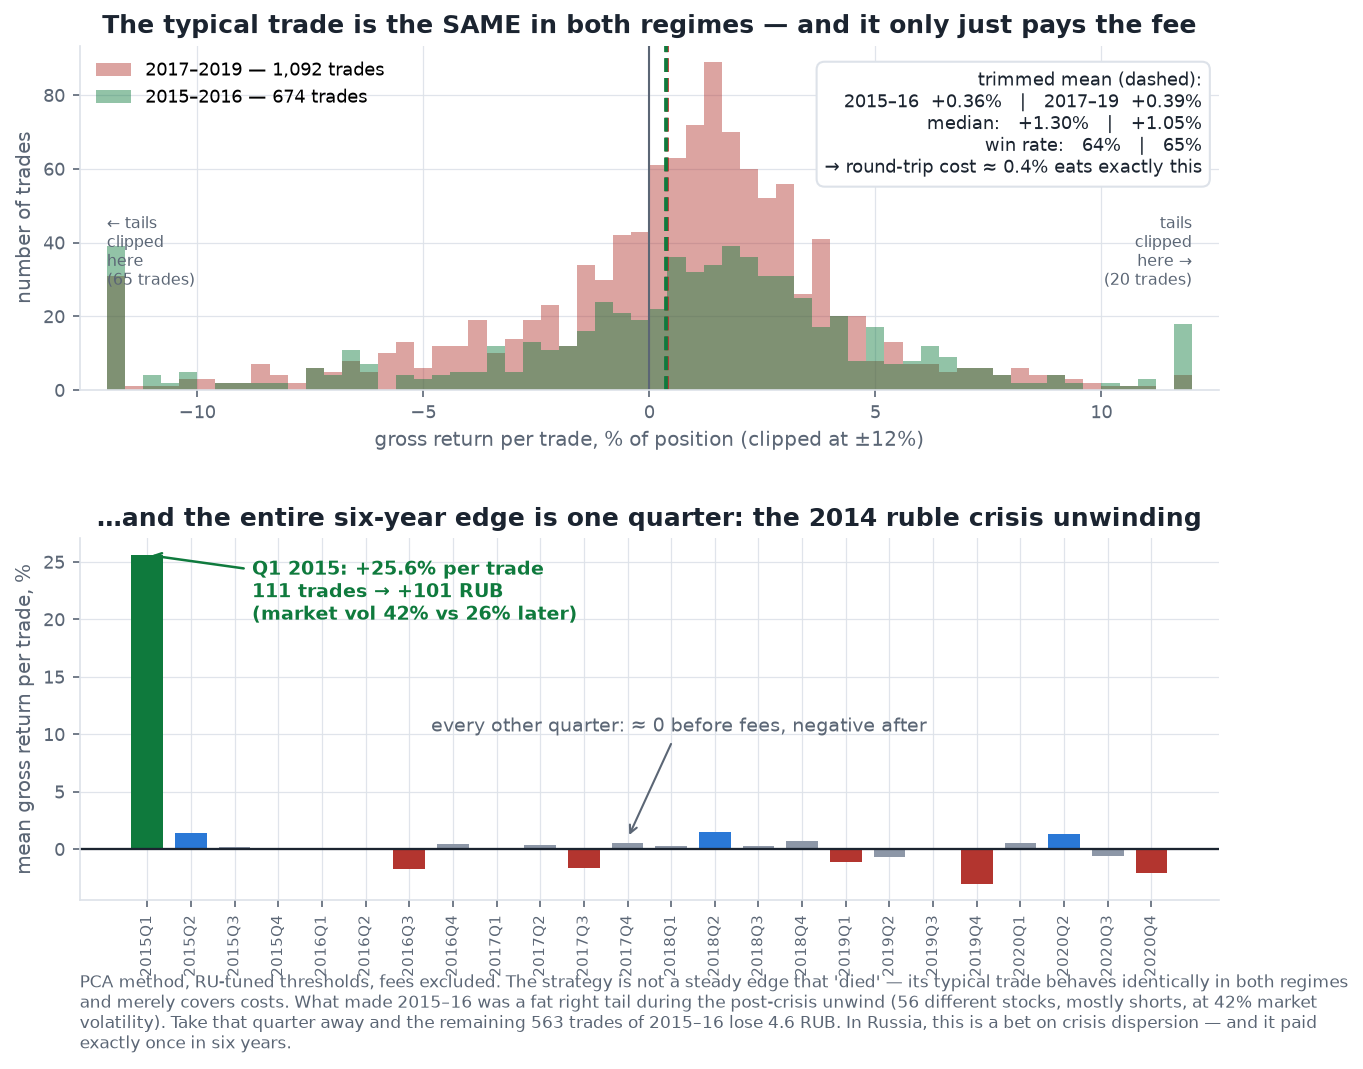

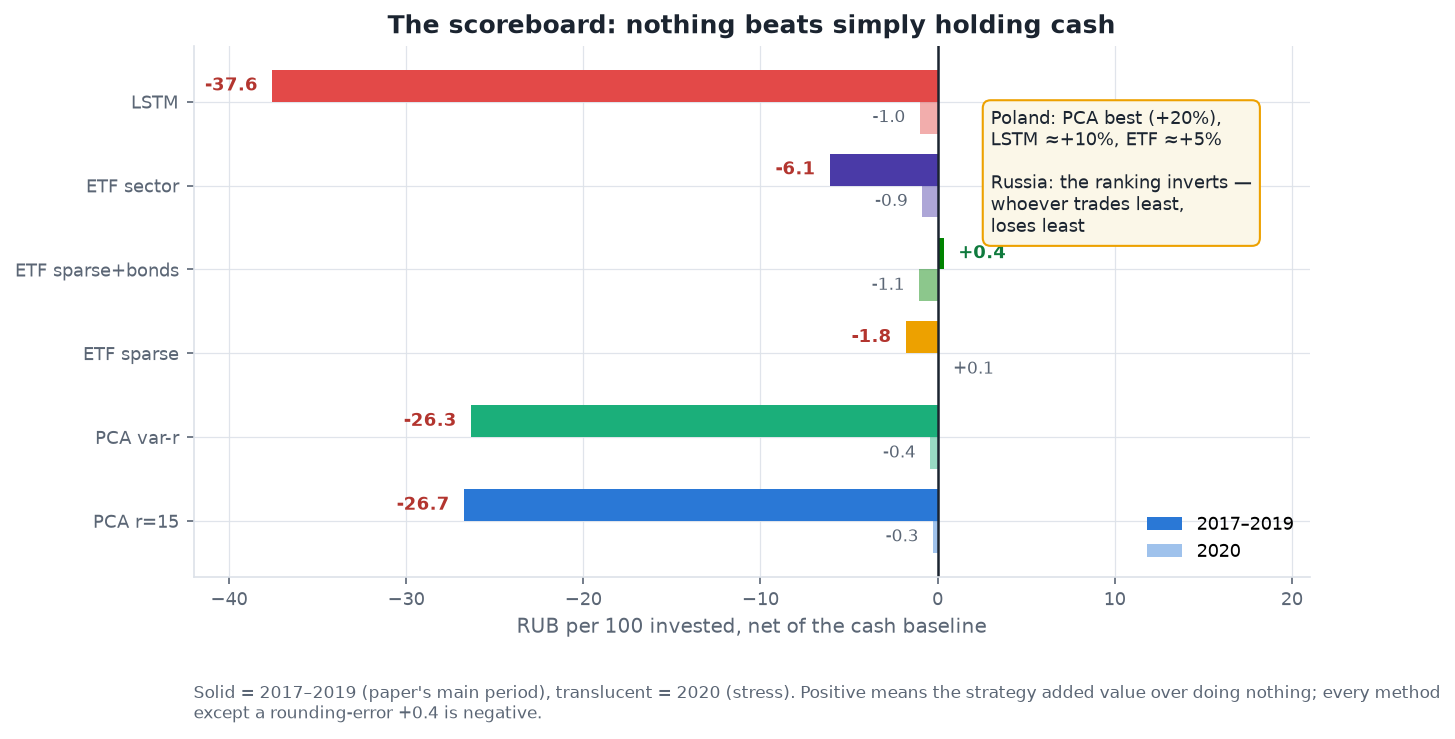

In [16]:
from IPython.display import Image, display as show
for f in ["01_anatomy_of_a_trade.png", "03_a_tail_bet_not_an_edge.png",
          "05_alpha_scoreboard.png"]:
    show(Image(filename=f"figures/{f}"))

## Appendix · Reproducing from zero

```bash
# 1. data (~20 min of MOEX ISS + dohod.ru requests; every step cached under data/)
python3 moex_data.py

# 2. engine sanity: synthetic OU market where the model is TRUE — must profit
python3 test_synthetic.py

# 3. all deterministic experiments (transfer test + 2015-16 grid + reruns) → results/
python3 run_experiments.py all

# 4. LSTM (≈4 h: 240 stock-year models, cached & resumable) → results/summary_lstm.json
python3 run_lstm.py

# 5. figures (figures/*.png)
python3 make_figures.py
```

Data sources: MOEX ISS (candles, index history, historical index compositions,
`zcyc` yield curve, dividends) and dohod.ru (pre-2018 dividend records). No API keys.
The engine found one genuine trap worth remembering: **ISS candles are retroactively
split-adjusted while dividends are as-paid** — always rescale dividends by the
candle/as-traded price ratio (`moex_data.fetch_basis_factors`).